In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [4]:
df = pd.read_csv('NFLX.csv')

df['Data'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop = True)

In [5]:
series = df['Close']
print(f"Loaded {len(series)} rows of Netflix stock data.")
print(df[['Data', 'Close']].head())

Loaded 1009 rows of Netflix stock data.
        Data       Close
0 2018-02-05  254.259995
1 2018-02-06  265.720001
2 2018-02-07  264.559998
3 2018-02-08  250.100006
4 2018-02-09  249.470001


In [7]:
print("\n--- Training Machine Learning (XGBoost) Model ---")

ml_df = pd.DataFrame({'Close': series})

for lag in range(1, 4):
    ml_df[f'lag_{lag}'] = ml_df['Close'].shift(lag)

ml_df.dropna(inplace = True)

X = ml_df[['lag_1', 'lag_2', 'lag_3']]
y = ml_df['Close']

train_size = int(len(X) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

ml_model = xgb.XGBRegressor(objective = 'reg:squarederror', n_estimators = 100, learning_rate = 0.05)
ml_model.fit(X_train, y_train)

ml_preds = ml_model.predict(X_test)
ml_rmse = np.sqrt(mean_squared_error(y_test, ml_preds))
print(f"XGBoost MSE: ${ml_rmse:.2f}")


--- Training Machine Learning (XGBoost) Model ---
XGBoost MSE: $53.62


In [9]:
print("\n--- Training Deep Learning (LSTM) Model ---")

values = series.values.reshape(-1, 1)
mean, std = values.mean(), values.std()
scaled_values = (values - mean)/std


def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
        ys.append(data[i + seq_length])
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 10
X_dl, y_dl = create_sequences(scaled_values, SEQ_LENGTH)

dl_train_size = int(len(X_dl) * 0.8)
X_train_dl, X_test_dl = X_dl[:dl_train_size], X_dl[dl_train_size:]
y_train_dl, y_test_dl = y_dl[:dl_train_size], y_dl[dl_train_size:]

train_dataset = TensorDataset(torch.tensor(X_train_dl, dtype = torch.float32), torch.tensor(y_train_dl, dtype = torch.float32))
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = False)


--- Training Deep Learning (LSTM) Model ---


In [14]:
class TimeSeriesLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(TimeSeriesLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first = True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


dl_model = TimeSeriesLSTM(input_dim = 1, hidden_dim = 64, output_dim = 1, num_layers = 2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(dl_model.parameters(), lr = 0.01)

dl_model.train()
for epoch in range(25):
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = dl_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

dl_model.eval()
with torch.no_grad():
    test_tensor = torch.tensor(X_test_dl, dtype = torch.float32)
    dl_preds_scaled = dl_model(test_tensor).numpy()

dl_preds = (dl_preds_scaled * std) + mean
y_test_original = (y_test_dl * std) + mean

dl_rmse = np.sqrt(mean_squared_error(y_test_original, dl_preds))
print(f"LSTM RMSE: ${dl_rmse:.2f}")

LSTM RMSE: $54.92


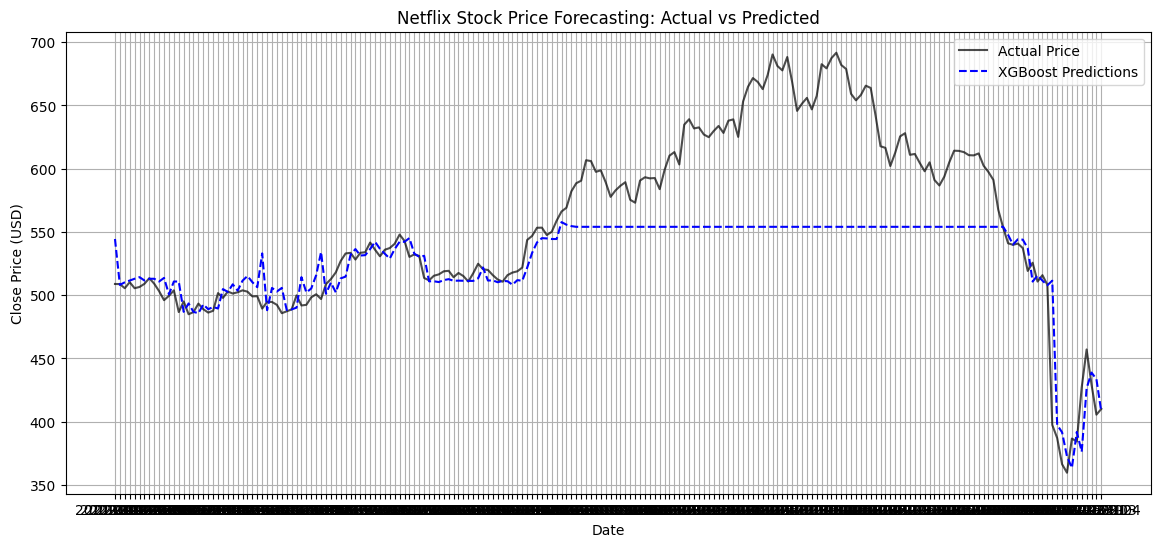

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'].iloc[-len(y_test):], y_test, label='Actual Price', color='black', alpha=0.7)
plt.plot(df['Date'].iloc[-len(y_test):], ml_preds, label='XGBoost Predictions', color='blue', linestyle='--')
plt.title('Netflix Stock Price Forecasting: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()